# Conférences Python Master TIDE #3

## A) Taux de change

On va s'intéresser au dataset des cours des devises de la Banque de France :
- https://webstat.banque-france.fr/fr/#/node/5385566

Les données sont dans le fichier `Webstat_Export.csv`.

L'idée est de charger les données, de les nettoyer et de pouvoir accéder aux cours de certaines devises à partir de leur code ISO3. On retiendra uniquement les colonnes se terminant effectivement par un code ISO3 entre parenthèses. Par ex., "Dollar des Etats-Unis (USD)".

1) Charger le fichier dans un DataFrame dont l'index doit correspondre aux dates, triées dans l'ordre chronologique et les colonnes doivent être les codes ISO3 des devises.

2) Sélectionner les devises : ['USD', 'CHF', 'GBP', 'JPY', 'TRY', 'CNY']

3) Calculer la moyenne des taux de change par année. Voir les codes de resampling : https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects

4) Faire des graphiques avec :
- Les taux de change divisés par leur moyenne.
- Les taux de change divisés par leur moyenne avec une moyenne glissante de 30 jours ou bien un maximum glissant de 100 jours.
- Les taux de change divisés par la dernière valeur connue avec une moyenne glissante de 30 jours.

5) Réindexer le DataFrame en prenant toutes les dates et compléter les valeurs manquantes par interpolation linéaire.

6) Avec la librairie **sparklines** afficher un DataFrame avec la moyenne annuelle des taux de change pour une monnaie donnée ainsi que la tendance par trimestre.

```python
import sparklines

print(sparklines.sparklines(pd.Series(range(8)))[0])
```

## B) Données télécom

Dataset des opérateurs télécom : `couverture-2g-3g-4g-en-france-par-operateur-juillet-2015.csv`

1) Chargez le fichier dans un DataFrame.

2) Transformez ce DataFrame large en un DataFrame long en isolant les colonnes d'identification d'une part et les colonnes de valeurs de couverture d'autre part.

3) Rajoutez 3 colonnes "Opérateur", "Type Couverture" et "Réseau" calculées à partir de la colonne "variable" obtenue en 2.

4) Chargez le DataFrame des communes déjà utilisé et effectuez une jointure sur le code INSEE.

6) Pour le réseau 4G et la couverture surfacique, calculez la moyenne des couvertures par statut de commune et par opérateur. Pour quel couple (statut, opérateur) a-t-on la moyenne de la couverture la plus faible ?

## C) Données RH

Dataset de StackOverflow : `survey_results_public_2022.zip`

1) Charger le fichier dans un DataFrame.

2) Sélectionner une colonne se terminant par "HaveWorkedWith" ou "WantToWorkWith" et la transformer en données numériques 0 ou 1 en utilisant la méthode `get_dummies()` de **pandas**.

3) Calculer un score en sommant les valeurs de chaque participant et afficher un diagramme de type box.

4) Considérer les colonnes "Age", "MainBranch" et "RemoteWork". En utilisant la classe `OneHotEncoder` de la librairie **scikit-learn** transformer ces colonnes en données numériques.


&copy; Francis Wolinski 2023

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
taux_changes = pd.read_csv("data/Webstat_Export.csv",
                           sep=";",
                           skiprows=[1, 2],
                           decimal=",",
                           na_values=["", "-"])
taux_changes

,Titre :,"Taux de change effectif réel - 36 partenaires commerciaux, variation sur 3 ans",Taux de change effectif réel - 16 partenaires commerciaux (zone euro),Dollar australien (AUD),Lev bulgare (BGN),Real brésilien (BRL),Dollar canadien (CAD),Franc suisse (CHF),Yuan renminbi chinois (CNY),Livre chypriote (CYP),...,Dollar de Singapour (SGD).1,Cours de change de l'euro contre dollar de Singapour (SGD) - fin de mois,Baht thaïlandais (THB).1,Cours de change de l'euro contre baht thaïlandais (THB) - fin de mois,Livre turque (TRY).1,Cours de change de l'euro contre nouvelle livre turque (TRY) - fin de mois,Dollar des Etats-Unis (USD).1,Cours de change de l'euro contre dollar des Etats-Unis (USD) - fin de mois,Rand sud-africain (ZAR).1,Cours de change de l'euro contre rand sud-africain (ZAR) - fin de mois
0,08/12/2023,NaN,NaN,1.6327,1.9558,5.2933,1.4627,0.9438,7.7179,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,07/12/2023,NaN,NaN,1.6407,1.9558,5.2614,1.4656,0.9446,7.7058,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,06/12/2023,NaN,NaN,1.6391,1.9558,5.2994,1.4616,0.9429,7.7148,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05/12/2023,NaN,NaN,1.6492,1.9558,5.3636,1.4700,0.9456,7.7269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,04/12/2023,NaN,NaN,1.6351,1.9558,5.3175,1.4716,0.9476,7.7580,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9101,07/01/1999,NaN,NaN,1.8474,NaN,NaN,1.7602,1.6165,NaN,0.58187,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9102,06/01/1999,NaN,NaN,1.8820,NaN,NaN,1.7711,1.6116,NaN,0.58200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9103,05/01/1999,NaN,NaN,1.8944,NaN,NaN,1.7965,1.6123,NaN,0.58230,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9104,04/01/1999,NaN,NaN,1.9100,NaN,NaN,1.8004,1.6168,NaN,0.58231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
taux_changes.dtypes

Titre :                                                                            object
Taux de change effectif réel - 36 partenaires commerciaux, variation sur 3 ans    float64
Taux de change effectif réel - 16 partenaires commerciaux (zone euro)             float64
Dollar australien (AUD)                                                           float64
Lev bulgare (BGN)                                                                 float64
                                                                                   ...   
Cours de change de l'euro contre nouvelle livre turque (TRY) - fin de mois        float64
Dollar des Etats-Unis (USD).1                                                     float64
Cours de change de l'euro contre dollar des Etats-Unis (USD) - fin de mois        float64
Rand sud-africain (ZAR).1                                                         float64
Cours de change de l'euro contre rand sud-africain (ZAR) - fin de mois            float64
Length: 10

In [15]:
taux_changes.iloc[0, 3]

1.6327

In [21]:
header = pd.Series(taux_changes.columns).str.extract("\(([A-Z]{3})\)$", expand=False).values
header[0] = "Date"
header

array(['Date', nan, nan, 'AUD', 'BGN', 'BRL', 'CAD', 'CHF', 'CNY', 'CYP',
       'CZK', 'DKK', 'EEK', nan, 'GBP', 'HKD', 'HRK', 'HUF', 'IDR', 'ILS',
       nan, 'ISK', 'JPY', 'KRW', 'LTL', 'LVL', 'MTL', 'MXN', 'MYR', 'NOK',
       'NZD', 'PHP', 'PLN', 'RON', 'RUB', 'SEK', 'SGD', 'SIT', 'SKK',
       'THB', 'TRY', 'USD', nan, 'ZAR', nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan], dtype=object)

In [32]:
taux_changes.columns = header
taux_changes["Date"] = pd.to_datetime(taux_changes["Date"], format="%d/%m/%Y")
taux_changes = taux_changes.set_index("Date")
taux_changes = taux_changes.sort_index()
taux_changes = taux_changes[['USD', 'CHF', 'GBP', 'JPY', 'TRY', 'CNY']]
taux_changes = taux_changes.dropna()
taux_changes

,USD,CHF,GBP,JPY,TRY,CNY
Date,,,,,,
2000-01-13,1.0276,1.6111,0.62550,108.89,0.5555,8.5054
2000-01-14,1.0225,1.6130,0.62210,108.05,0.5536,8.4632
2000-01-17,1.0094,1.6136,0.61800,105.81,0.5523,8.3548
2000-01-18,1.0093,1.6131,0.61740,106.42,0.5521,8.3540
2000-01-19,1.0105,1.6120,0.61720,106.99,0.5523,8.3639
...,...,...,...,...,...,...
2023-12-04,1.0868,0.9476,0.85790,159.47,31.3983,7.7580
2023-12-05,1.0817,0.9456,0.85723,159.13,31.2925,7.7269
2023-12-06,1.0778,0.9429,0.85610,158.70,31.1921,7.7148


In [34]:
taux_changes.loc["12/2022":"01/2023"]

,USD,CHF,GBP,JPY,TRY,CNY
Date,,,,,,
2022-12-01,1.0454,0.9868,0.85715,142.48,19.4778,7.3965
2022-12-02,1.0538,0.9834,0.85855,141.32,19.6392,7.3971
2022-12-05,1.0587,0.9893,0.86085,143.07,19.7326,7.3573
2022-12-06,1.0516,0.9872,0.86170,143.33,19.6010,7.3494
2022-12-07,1.0529,0.9893,0.86408,144.44,19.6256,7.3476
2022-12-08,1.0519,0.9889,0.86258,143.75,19.6114,7.3324
2022-12-09,1.0559,0.9856,0.85950,143.30,19.6872,7.3475
2022-12-12,1.0562,0.9855,0.86006,144.86,19.6913,7.3670
2022-12-13,1.0545,0.9869,0.85753,144.85,19.6649,7.3637


In [36]:
taux_changes.resample("M").mean()

,USD,CHF,GBP,JPY,TRY,CNY
Date,,,,,,
2000-01-31,1.004985,1.612115,0.612831,106.091538,0.551685,8.318246
2000-02-29,0.983424,1.606886,0.614657,107.640952,0.553943,8.139800
2000-03-31,0.964343,1.604243,0.610626,102.590870,0.559330,7.981870
2000-04-30,0.946950,1.573956,0.598017,99.924444,0.563789,7.837911
2000-05-31,0.905968,1.556164,0.601509,98.090455,0.559123,7.498705
...,...,...,...,...,...,...
2023-08-31,1.090887,0.958752,0.858921,157.962174,29.378817,7.909583
2023-09-30,1.068381,0.959995,0.861584,157.795238,28.864348,7.796667
2023-10-31,1.056255,0.954732,0.867984,158.037727,29.450595,7.719995


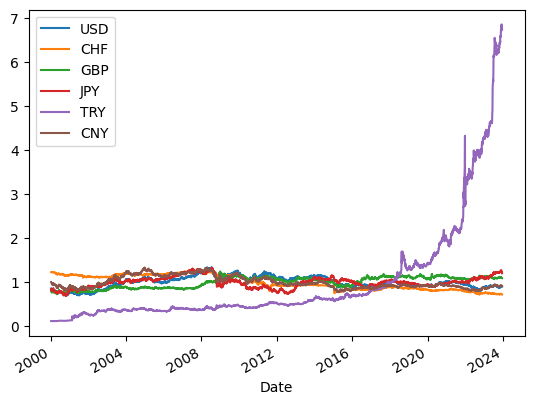

In [39]:
(taux_changes / taux_changes.mean()).plot.line();

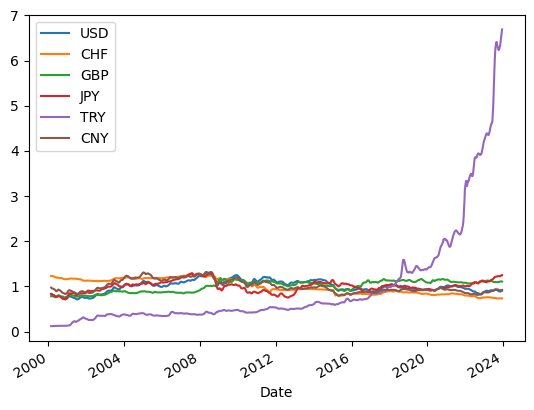

In [40]:
(taux_changes / taux_changes.mean()).rolling(30).mean().plot.line();

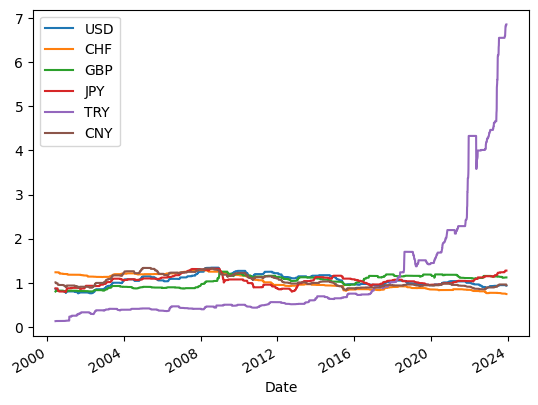

In [41]:
(taux_changes / taux_changes.mean()).rolling(100).max().plot.line();

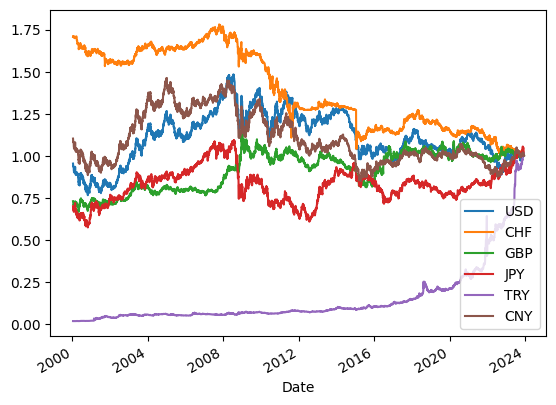

In [45]:
(taux_changes / taux_changes.iloc[-1]).plot.line();

In [46]:
taux_changes

,USD,CHF,GBP,JPY,TRY,CNY
Date,,,,,,
2000-01-13,1.0276,1.6111,0.62550,108.89,0.5555,8.5054
2000-01-14,1.0225,1.6130,0.62210,108.05,0.5536,8.4632
2000-01-17,1.0094,1.6136,0.61800,105.81,0.5523,8.3548
2000-01-18,1.0093,1.6131,0.61740,106.42,0.5521,8.3540
2000-01-19,1.0105,1.6120,0.61720,106.99,0.5523,8.3639
...,...,...,...,...,...,...
2023-12-04,1.0868,0.9476,0.85790,159.47,31.3983,7.7580
2023-12-05,1.0817,0.9456,0.85723,159.13,31.2925,7.7269
2023-12-06,1.0778,0.9429,0.85610,158.70,31.1921,7.7148


In [49]:
dates = pd.date_range(start=taux_changes.index[0], end=taux_changes.index[-1], freq="D")
dates

DatetimeIndex(['2000-01-13', '2000-01-14', '2000-01-15', '2000-01-16',
               '2000-01-17', '2000-01-18', '2000-01-19', '2000-01-20',
               '2000-01-21', '2000-01-22',
               ...
               '2023-11-29', '2023-11-30', '2023-12-01', '2023-12-02',
               '2023-12-03', '2023-12-04', '2023-12-05', '2023-12-06',
               '2023-12-07', '2023-12-08'],
              dtype='datetime64[ns]', length=8731, freq='D')

In [50]:
taux_changes = taux_changes.reindex(dates)
taux_changes

,USD,CHF,GBP,JPY,TRY,CNY
2000-01-13,1.0276,1.6111,0.62550,108.89,0.5555,8.5054
2000-01-14,1.0225,1.6130,0.62210,108.05,0.5536,8.4632
2000-01-15,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-16,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-17,1.0094,1.6136,0.61800,105.81,0.5523,8.3548
...,...,...,...,...,...,...
2023-12-04,1.0868,0.9476,0.85790,159.47,31.3983,7.7580
2023-12-05,1.0817,0.9456,0.85723,159.13,31.2925,7.7269
2023-12-06,1.0778,0.9429,0.85610,158.70,31.1921,7.7148
2023-12-07,1.0771,0.9446,0.85750,156.18,31.1627,7.7058


In [53]:
#taux_changes.fillna(method="ffill")
#taux_changes.fillna(method="bfill")
taux_changes.interpolate()

,USD,CHF,GBP,JPY,TRY,CNY
2000-01-13,1.027600,1.6111,0.625500,108.890000,0.555500,8.505400
2000-01-14,1.022500,1.6130,0.622100,108.050000,0.553600,8.463200
2000-01-15,1.018133,1.6132,0.620733,107.303333,0.553167,8.427067
2000-01-16,1.013767,1.6134,0.619367,106.556667,0.552733,8.390933
2000-01-17,1.009400,1.6136,0.618000,105.810000,0.552300,8.354800
...,...,...,...,...,...,...
2023-12-04,1.086800,0.9476,0.857900,159.470000,31.398300,7.758000
2023-12-05,1.081700,0.9456,0.857230,159.130000,31.292500,7.726900
2023-12-06,1.077800,0.9429,0.856100,158.700000,31.192100,7.714800
2023-12-07,1.077100,0.9446,0.857500,156.180000,31.162700,7.705800


In [54]:
taux_changes.iloc[1:5]

,USD,CHF,GBP,JPY,TRY,CNY
2000-01-14,1.0225,1.6130,0.6221,108.05,0.5536,8.4632
2000-01-15,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-16,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-17,1.0094,1.6136,0.6180,105.81,0.5523,8.3548


In [55]:
np.linspace(taux_changes.iloc[1], taux_changes.iloc[4], 4)

array([[  1.0225    ,   1.613     ,   0.6221    , 108.05      ,
          0.5536    ,   8.4632    ],
       [  1.01813333,   1.6132    ,   0.62073333, 107.30333333,
          0.55316667,   8.42706667],
       [  1.01376667,   1.6134    ,   0.61936667, 106.55666667,
          0.55273333,   8.39093333],
       [  1.0094    ,   1.6136    ,   0.618     , 105.81      ,
          0.5523    ,   8.3548    ]])

In [ ]:
%pip install sparklines

In [56]:
import sparklines

In [57]:
print(sparklines.sparklines(pd.Series(range(8)))[0])

▁▂▃▄▅▆▇█


In [59]:
sparklines.sparklines(pd.Series(range(8)))

['▁▂▃▄▅▆▇█']

In [62]:
taux_changes.resample("A").agg(moyenne=('TRY', lambda s: s.mean().round(3)),
                               tendance=('TRY', lambda s: sparklines.sparklines(s.resample("Q").mean())[0]))

,moyenne,tendance
2000-12-31,0.576,▁▄▇█
2001-12-31,1.102,▁▄▇█
2002-12-31,1.440,▁▃██
2003-12-31,1.695,█▆▁▆
2004-12-31,1.777,▁▄▆█
2005-12-31,1.677,█▇▂▁
2006-12-31,1.809,▁▇█▇
2007-12-31,1.786,█▅▃▁
2008-12-31,1.906,▁▆▂█
2009-12-31,2.163,▄▁▁█


In [63]:
telco = pd.read_csv("data/couverture-2g-3g-4g-en-france-par-operateur-juillet-2015.csv", sep=";")
telco

,CODE POSTAL,CODE INSEE,NOM COMMUNE,CODE DEPARTEMENT,SURFACE COMMUNE (km²),POPULATION COMMUNE,Orange France Couverture population 4G,Bouygues Telecom Couverture population 4G,SFR Couverture population 4G,Free Mobile Couverture population 4G,...,Bouygues Telecom Couverture population 2G,SFR Couverture population 2G,Free Mobile Couverture population 2G,Par au moins un opérateur Couverture population 2G,Orange France Couverture surfacique 2G,Bouygues Telecom Couverture surfacique 2G,SFR Couverture surfacique 2G,Free Mobile Couverture surfacique 2G,Par au moins un opérateur Couverture surfacique 2G,coordonnees
0,17510,17105,CHIVES,17,20.642005,355.32,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,0.99,1.00,1.00,1.0,"45.9508835378, -0.121918052323"
1,17600,17112,LA CLISSE,17,4.896771,591.78,0.09,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"45.7320429784, -0.75493581331"
2,17150,17116,CONSAC,17,8.915911,239.74,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"45.4182495786, -0.588917528415"
3,17130,17118,CORIGNAC,17,10.850210,358.69,0.00,0.00,0.00,0.0,...,0.63,1.0,1.0,1.0,0.99,0.85,1.00,0.99,1.0,"45.2448604983, -0.39280322021"
4,17330,17124,COURANT,17,15.586269,371.00,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"46.0375312829, -0.587834905531"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36589,70000,70378,NAVENNE,70,3.826265,1847.69,1.00,1.00,0.99,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"47.6030208472, 6.1618556725"
36590,70000,70388,NOIDANS-LES-VESOUL,70,8.634594,2159.19,0.99,0.95,0.36,0.0,...,1.00,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.0,"47.6097514089, 6.11842989879"
36591,70100,70389,NOIRON,70,5.768295,64.01,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,0.98,0.96,1.00,1.0,"47.3828510502, 5.62597938451"
36592,70500,70399,ORMOY,70,19.577164,224.76,0.00,0.00,0.00,0.0,...,1.00,1.0,1.0,1.0,1.00,0.99,0.98,1.00,1.0,"47.8850612988, 5.99402771513"


In [85]:
columns = telco.columns[:6].tolist() + [telco.columns[-1]]
telco_long = telco.melt(id_vars=columns)
telco_long.columns = [col.lower() for col in columns] + ['variable', 'value']
telco_long

,code postal,code insee,nom commune,code departement,surface commune (km²),population commune,coordonnees,variable,value
0,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",Orange France Couverture population 4G,0.00
1,17600,17112,LA CLISSE,17,4.896771,591.78,"45.7320429784, -0.75493581331",Orange France Couverture population 4G,0.09
2,17150,17116,CONSAC,17,8.915911,239.74,"45.4182495786, -0.588917528415",Orange France Couverture population 4G,0.00
3,17130,17118,CORIGNAC,17,10.850210,358.69,"45.2448604983, -0.39280322021",Orange France Couverture population 4G,0.00
4,17330,17124,COURANT,17,15.586269,371.00,"46.0375312829, -0.587834905531",Orange France Couverture population 4G,0.00
...,...,...,...,...,...,...,...,...,...
1097815,70000,70378,NAVENNE,70,3.826265,1847.69,"47.6030208472, 6.1618556725",Par au moins un opérateur Couverture surfaciqu...,1.00
1097816,70000,70388,NOIDANS-LES-VESOUL,70,8.634594,2159.19,"47.6097514089, 6.11842989879",Par au moins un opérateur Couverture surfaciqu...,1.00
1097817,70100,70389,NOIRON,70,5.768295,64.01,"47.3828510502, 5.62597938451",Par au moins un opérateur Couverture surfaciqu...,1.00
1097818,70500,70399,ORMOY,70,19.577164,224.76,"47.8850612988, 5.99402771513",Par au moins un opérateur Couverture surfaciqu...,1.00


In [72]:
telco.shape

(36594, 37)

In [73]:
telco_long.shape

(1097820, 9)

In [74]:
36594 * 30

1097820

In [80]:
telco_long["variable"]

0                     Orange France Couverture population 4G
1                     Orange France Couverture population 4G
2                     Orange France Couverture population 4G
3                     Orange France Couverture population 4G
4                     Orange France Couverture population 4G
                                 ...                        
1097815    Par au moins un opérateur Couverture surfaciqu...
1097816    Par au moins un opérateur Couverture surfaciqu...
1097817    Par au moins un opérateur Couverture surfaciqu...
1097818    Par au moins un opérateur Couverture surfaciqu...
1097819    Par au moins un opérateur Couverture surfaciqu...
Name: variable, Length: 1097820, dtype: object

In [86]:
telco_long[["opérateur", "couverture", "technologie"]] = telco_long["variable"].str.extract("(.*) (Couverture [a-z]+) ([2-4]G)$")
telco_long = telco_long.drop("variable", axis=1)
telco_long

,code postal,code insee,nom commune,code departement,surface commune (km²),population commune,coordonnees,value,opérateur,couverture,technologie
0,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",0.00,Orange France,Couverture population,4G
1,17600,17112,LA CLISSE,17,4.896771,591.78,"45.7320429784, -0.75493581331",0.09,Orange France,Couverture population,4G
2,17150,17116,CONSAC,17,8.915911,239.74,"45.4182495786, -0.588917528415",0.00,Orange France,Couverture population,4G
3,17130,17118,CORIGNAC,17,10.850210,358.69,"45.2448604983, -0.39280322021",0.00,Orange France,Couverture population,4G
4,17330,17124,COURANT,17,15.586269,371.00,"46.0375312829, -0.587834905531",0.00,Orange France,Couverture population,4G
...,...,...,...,...,...,...,...,...,...,...,...
1097815,70000,70378,NAVENNE,70,3.826265,1847.69,"47.6030208472, 6.1618556725",1.00,Par au moins un opérateur,Couverture surfacique,2G
1097816,70000,70388,NOIDANS-LES-VESOUL,70,8.634594,2159.19,"47.6097514089, 6.11842989879",1.00,Par au moins un opérateur,Couverture surfacique,2G
1097817,70100,70389,NOIRON,70,5.768295,64.01,"47.3828510502, 5.62597938451",1.00,Par au moins un opérateur,Couverture surfacique,2G
1097818,70500,70399,ORMOY,70,19.577164,224.76,"47.8850612988, 5.99402771513",1.00,Par au moins un opérateur,Couverture surfacique,2G


In [88]:
geo = (pd
      .read_csv("data/correspondance-code-insee-code-postal.csv",
                sep=";",
                usecols=range(11))
     )

In [89]:
data = pd.merge(telco_long,
                geo,
                left_on="code insee",
                right_on="Code INSEE",
                how="left")

data.head()

,code postal,code insee,nom commune,code departement,surface commune (km²),population commune,coordonnees,value,opérateur,couverture,...,Code Postal,Commune,Département,Région,Statut,Altitude Moyenne,Superficie,Population,geo_point_2d,geo_shape
0,17510,17105,CHIVES,17,20.642005,355.32,"45.9508835378, -0.121918052323",0.00,Orange France,Couverture population,...,17510,CHIVES,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,108.0,2062.0,0.4,"45.9508835378, -0.121918052323","{""type"": ""Polygon"", ""coordinates"": [[[-0.10484..."
1,17600,17112,LA CLISSE,17,4.896771,591.78,"45.7320429784, -0.75493581331",0.09,Orange France,Couverture population,...,17600,LA CLISSE,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,34.0,524.0,0.6,"45.7320429784, -0.75493581331","{""type"": ""Polygon"", ""coordinates"": [[[-0.74528..."
2,17150,17116,CONSAC,17,8.915911,239.74,"45.4182495786, -0.588917528415",0.00,Orange France,Couverture population,...,17150,CONSAC,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,58.0,905.0,0.2,"45.4182495786, -0.588917528415","{""type"": ""Polygon"", ""coordinates"": [[[-0.60200..."
3,17130,17118,CORIGNAC,17,10.850210,358.69,"45.2448604983, -0.39280322021",0.00,Orange France,Couverture population,...,17130,CORIGNAC,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,69.0,1112.0,0.3,"45.2448604983, -0.39280322021","{""type"": ""Polygon"", ""coordinates"": [[[-0.41318..."
4,17330,17124,COURANT,17,15.586269,371.00,"46.0375312829, -0.587834905531",0.00,Orange France,Couverture population,...,17330,COURANT,CHARENTE-MARITIME,POITOU-CHARENTES,Commune simple,55.0,1574.0,0.4,"46.0375312829, -0.587834905531","{""type"": ""Polygon"", ""coordinates"": [[[-0.58528..."


In [91]:
data.head().T

,0,1,2,3,4
code postal,17510,17600,17150,17130,17330
code insee,17105,17112,17116,17118,17124
nom commune,CHIVES,LA CLISSE,CONSAC,CORIGNAC,COURANT
code departement,17,17,17,17,17
surface commune (km²),20.642005,4.896771,8.915911,10.85021,15.586269
population commune,355.32,591.78,239.74,358.69,371.0
coordonnees,"45.9508835378, -0.121918052323","45.7320429784, -0.75493581331","45.4182495786, -0.588917528415","45.2448604983, -0.39280322021","46.0375312829, -0.587834905531"
value,0.0,0.09,0.0,0.0,0.0
opérateur,Orange France,Orange France,Orange France,Orange France,Orange France
couverture,Couverture population,Couverture population,Couverture population,Couverture population,Couverture population


In [93]:
selection = data.loc[(data.couverture=="Couverture surfacique") & (data.technologie=="4G")]
selection.groupby("Statut")["value"].mean()

Statut
Capitale d'état         0.996000
Chef-lieu canton        0.302156
Commune simple          0.201893
Préfecture              0.724730
Préfecture de région    0.893238
Sous-préfecture         0.449766
Name: value, dtype: float64

In [95]:
selection.groupby(["Statut", "opérateur"])["value"].mean().idxmin()

('Commune simple', 'Free Mobile')

In [102]:
selection.pivot_table(index="opérateur",
                      columns="Statut",
                      values="value").stack().idxmin()

('Free Mobile', 'Commune simple')

In [103]:
survey = pd.read_csv("data/survey_results_public_2022.zip")

survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73268 entries, 0 to 73267
Data columns (total 79 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ResponseId                      73268 non-null  int64  
 1   MainBranch                      73268 non-null  object 
 2   Employment                      71709 non-null  object 
 3   RemoteWork                      58958 non-null  object 
 4   CodingActivities                58899 non-null  object 
 5   EdLevel                         71571 non-null  object 
 6   LearnCode                       71580 non-null  object 
 7   LearnCodeOnline                 50685 non-null  object 
 8   LearnCodeCoursesCert            29389 non-null  object 
 9   YearsCode                       71331 non-null  object 
 10  YearsCodePro                    51833 non-null  object 
 11  DevType                         61302 non-null  object 
 12  OrgSize                         

In [105]:
survey["LanguageHaveWorkedWith"].str.get_dummies(";")

,APL,Assembly,Bash/Shell,C,C#,C++,COBOL,Clojure,Crystal,Dart,...,R,Ruby,Rust,SAS,SQL,Scala,Solidity,Swift,TypeScript,VBA
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73263,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
73264,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
73265,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
73266,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


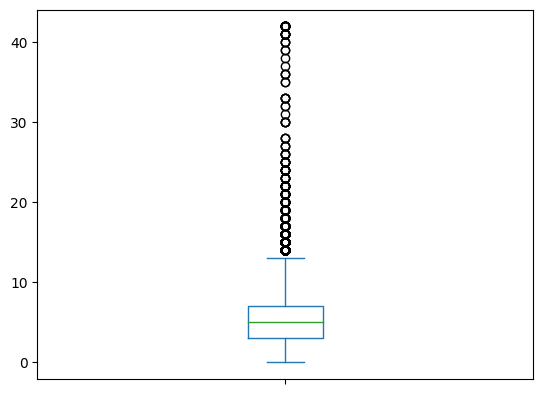

In [108]:
survey["LanguageHaveWorkedWith"].str.get_dummies(";").sum(axis=1).plot.box();

In [109]:
survey[["Age", "MainBranch", "RemoteWork"]]

,Age,MainBranch,RemoteWork
0,NaN,None of these,NaN
1,NaN,I am a developer by profession,Fully remote
2,25-34 years old,"I am not primarily a developer, but I write co...","Hybrid (some remote, some in-person)"
3,35-44 years old,I am a developer by profession,Fully remote
4,25-34 years old,I am a developer by profession,"Hybrid (some remote, some in-person)"
...,...,...,...
73263,25-34 years old,I am a developer by profession,Fully remote
73264,25-34 years old,I am a developer by profession,Full in-person
73265,55-64 years old,"I am not primarily a developer, but I write co...","Hybrid (some remote, some in-person)"
73266,55-64 years old,I am a developer by profession,"Hybrid (some remote, some in-person)"


In [112]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
m = encoder.fit_transform(survey[["Age", "MainBranch", "RemoteWork"]])

In [123]:
m.sum() / (m.shape[0]*m.shape[1])

0.15789473684210525

In [127]:
pd.DataFrame(m.toarray(), columns=encoder.get_feature_names_out())

,Age_18-24 years old,Age_25-34 years old,Age_35-44 years old,Age_45-54 years old,Age_55-64 years old,Age_65 years or older,Age_Prefer not to say,Age_Under 18 years old,Age_nan,MainBranch_I am a developer by profession,MainBranch_I am learning to code,"MainBranch_I am not primarily a developer, but I write code sometimes as part of my work",MainBranch_I code primarily as a hobby,"MainBranch_I used to be a developer by profession, but no longer am",MainBranch_None of these,RemoteWork_Full in-person,RemoteWork_Fully remote,"RemoteWork_Hybrid (some remote, some in-person)",RemoteWork_nan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73263,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
73264,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
73265,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
73266,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [126]:
encoder.get_feature_names_out()

array(['Age_18-24 years old', 'Age_25-34 years old',
       'Age_35-44 years old', 'Age_45-54 years old',
       'Age_55-64 years old', 'Age_65 years or older',
       'Age_Prefer not to say', 'Age_Under 18 years old', 'Age_nan',
       'MainBranch_I am a developer by profession',
       'MainBranch_I am learning to code',
       'MainBranch_I am not primarily a developer, but I write code sometimes as part of my work',
       'MainBranch_I code primarily as a hobby',
       'MainBranch_I used to be a developer by profession, but no longer am',
       'MainBranch_None of these', 'RemoteWork_Full in-person',
       'RemoteWork_Fully remote',
       'RemoteWork_Hybrid (some remote, some in-person)',
       'RemoteWork_nan'], dtype=object)